# Efficient Adaptation of Large Language Models for Question Answering on Historical American Newspapers using LoRA

**Model:** `microsoft/phi-3.5-mini-instruct`  
**Dataset:** ChroniclingAmericaQA  
**Method:** QLoRA (4-bit quantization + LoRA adapters via PEFT)

---

## Overview

This notebook implements an end-to-end pipeline for fine-tuning a small LLM on a historical newspaper QA task:

1. Load and inspect the ChroniclingAmericaQA dataset
2. Establish a zero-shot baseline
3. Fine-tune with QLoRA for parameter-efficient adaptation
4. Evaluate using Exact Match, Token F1, and ROUGE-L
5. Analyze errors and save all outputs

**Hardware note:** All dataset sizes and batch sizes are configurable. Start with small subsets (e.g., `max_train_samples=200`) to verify the pipeline before scaling up.

---
## 1. Setup and Imports

In [ ]:
# Uncomment and run once to install dependencies
# !pip install datasets transformers peft trl bitsandbytes accelerate
# !pip install evaluate rouge_score sentencepiece
# !pip install pandas numpy tqdm
# !pip install torch torchvision torchaudio  # adjust for your CUDA version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 67.6 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
# Standard library
import os
import re
import json
import string
import warnings
from pathlib import Path
from collections import Counter

# Numeric / data
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Hugging Face ecosystem
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
    set_seed,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
    PeftModel,
)

# TRL >= 0.9: SFTConfig replaces TrainingArguments for SFT;
# DataCollatorForCompletionOnlyLM removed — use completion_only_loss in SFTConfig instead
from trl import SFTTrainer, SFTConfig

# Evaluation
import evaluate

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"TRL version     : {__import__('trl').__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

---
## 2. Configuration

All hyperparameters live here. Adjust before running any downstream cell.

In [ ]:
# ── Model ──────────────────────────────────────────────────────────────────
MODEL_NAME = "microsoft/phi-3.5-mini-instruct"

# ── Dataset ────────────────────────────────────────────────────────────────
DATASET_NAME = "Bhawna/ChroniclingAmericaQA"

# How many samples to use per split (None = use full split)
MAX_TRAIN_SAMPLES = 500    # set to None for full training set
MAX_DEV_SAMPLES   = 100
MAX_TEST_SAMPLES  = 200

# Whether to use raw OCR text instead of cleaned context
USE_RAW_OCR = False        # toggle for OCR vs clean context experiments

# ── Sequence lengths ───────────────────────────────────────────────────────
MAX_INPUT_LENGTH  = 1024   # prompt + context tokens
MAX_TARGET_LENGTH = 64     # max tokens to generate for an answer

# ── LoRA ───────────────────────────────────────────────────────────────────
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE             = 2    # per-device train batch size
EVAL_BATCH_SIZE        = 4
GRAD_ACCUMULATION      = 8    # effective batch = BATCH_SIZE * GRAD_ACCUMULATION
LEARNING_RATE          = 2e-4
NUM_EPOCHS             = 3
WARMUP_RATIO           = 0.05
WEIGHT_DECAY           = 0.01
LOGGING_STEPS          = 10
EVAL_STEPS             = 50
SAVE_STEPS             = 50
LOAD_BEST_AT_END       = True

# ── Infrastructure ─────────────────────────────────────────────────────────
SEED       = 42
# TODO: update output directory to your preferred path
OUTPUT_DIR = Path("./outputs/phi35_chronicling_qa")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
print("Configuration loaded.")
print(f"  Output directory : {OUTPUT_DIR.resolve()}")
print(f"  USE_RAW_OCR      : {USE_RAW_OCR}")
print(f"  Effective batch  : {BATCH_SIZE * GRAD_ACCUMULATION}")

---
## 3. Load Dataset

We load ChroniclingAmericaQA from the Hugging Face Hub. If the identifier needs updating, edit `DATASET_NAME` in Section 2.

In [ ]:
# TODO: If the dataset requires authentication, run:
#   from huggingface_hub import login; login(token="hf_YOUR_TOKEN_HERE")

print(f"Loading dataset: {DATASET_NAME} ...")

try:
    raw_datasets = load_dataset(DATASET_NAME)
except Exception as e:
    # TODO: If the dataset isn't on HF Hub, load from local files instead:
    # raw_datasets = load_dataset("json", data_files={
    #     "train": "path/to/train.json",
    #     "validation": "path/to/dev.json",
    #     "test": "path/to/test.json",
    # })
    raise RuntimeError(
        f"Could not load dataset '{DATASET_NAME}'. "
        "Update DATASET_NAME or load from local files (see TODO above)."
    ) from e

print("\nDataset splits:")
for split_name, split_data in raw_datasets.items():
    print(f"  {split_name:12s}: {len(split_data):>6,} examples")

print("\nColumn names:", raw_datasets[list(raw_datasets.keys())[0]].column_names)

In [ ]:
# Map split names to standard train / dev / test
# TODO: Adjust these keys if the dataset uses different split names
SPLIT_TRAIN = "train"
SPLIT_DEV   = "validation"   # may be 'dev' in some versions
SPLIT_TEST  = "test"

train_ds = raw_datasets[SPLIT_TRAIN]
dev_ds   = raw_datasets[SPLIT_DEV]
test_ds  = raw_datasets[SPLIT_TEST]

print(f"Train : {len(train_ds):,}")
print(f"Dev   : {len(dev_ds):,}")
print(f"Test  : {len(test_ds):,}")

---
## 4. Exploratory Data Inspection

Understand the data schema, typical answer lengths, and how much OCR noise is present.

In [ ]:
# Print a few raw examples
NUM_EXAMPLES_TO_SHOW = 3

for i, example in enumerate(train_ds.select(range(NUM_EXAMPLES_TO_SHOW))):
    print(f"{'='*70}")
    print(f"Example {i+1}")
    print(f"{'='*70}")
    # TODO: Update field names below to match actual dataset schema
    print(f"QUESTION : {example.get('question', 'N/A')}")
    print(f"ANSWER   : {example.get('answer', 'N/A')}")
    context = example.get('context', example.get('passage', 'N/A'))
    print(f"CONTEXT  : {str(context)[:300]}...")
    if 'raw_ocr' in example:
        print(f"RAW OCR  : {str(example['raw_ocr'])[:300]}...")
    print()

In [ ]:
# Field name aliases — update if dataset uses different keys
# TODO: Confirm these field names against actual dataset schema
FIELD_QUESTION = "question"
FIELD_ANSWER   = "answer"
FIELD_CONTEXT  = "context"      # cleaned / gold context
FIELD_RAW_OCR  = "raw_ocr"      # raw OCR text (may not exist)

HAS_RAW_OCR = FIELD_RAW_OCR in train_ds.column_names
print(f"Dataset has raw OCR field: {HAS_RAW_OCR}")

In [ ]:
# Length statistics
def compute_length_stats(dataset, field, label, n=None):
    """Compute token-approximate length stats for a text field."""
    subset = dataset.select(range(min(n or len(dataset), len(dataset))))
    lengths = [len(str(ex.get(field, "")).split()) for ex in subset]
    return {
        "field": label,
        "mean": np.mean(lengths),
        "median": np.median(lengths),
        "p95": np.percentile(lengths, 95),
        "max": np.max(lengths),
    }

stats_rows = [
    compute_length_stats(train_ds, FIELD_QUESTION, "Question"),
    compute_length_stats(train_ds, FIELD_ANSWER,   "Answer"),
    compute_length_stats(train_ds, FIELD_CONTEXT,  "Context (clean)"),
]
if HAS_RAW_OCR:
    stats_rows.append(compute_length_stats(train_ds, FIELD_RAW_OCR, "Context (OCR)"))

stats_df = pd.DataFrame(stats_rows).set_index("field").round(1)
print("Word-count statistics (train split):")
display(stats_df)

---
## 5. Preprocessing

Minimal, reversible preprocessing: choose OCR vs. clean context, normalize whitespace, handle missing values, and truncate long passages.

In [ ]:
def normalize_whitespace(text: str) -> str:
    """Collapse multiple spaces/newlines and strip leading/trailing whitespace."""
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def get_context(example: dict, use_raw_ocr: bool = False) -> str:
    """Return the appropriate context field, with fallback."""
    if use_raw_ocr and HAS_RAW_OCR:
        ctx = example.get(FIELD_RAW_OCR, "") or ""
    else:
        ctx = example.get(FIELD_CONTEXT, "") or ""
    return normalize_whitespace(str(ctx))


def truncate_words(text: str, max_words: int) -> str:
    """Hard-truncate text to max_words (word boundary, not token boundary)."""
    words = text.split()
    return " ".join(words[:max_words])


# Approximate word limit for context (generous; tokenizer may cut further)
CONTEXT_MAX_WORDS = int(MAX_INPUT_LENGTH * 0.6)


def preprocess_example(example: dict) -> dict:
    """Apply all preprocessing to a single dataset example."""
    question = normalize_whitespace(str(example.get(FIELD_QUESTION, "") or ""))
    answer   = normalize_whitespace(str(example.get(FIELD_ANSWER,   "") or ""))
    context  = get_context(example, use_raw_ocr=USE_RAW_OCR)
    context  = truncate_words(context, CONTEXT_MAX_WORDS)
    return {
        "question": question,
        "answer":   answer,
        "context":  context,
    }


print("Applying preprocessing ...")
train_clean = train_ds.map(preprocess_example, desc="Preprocess train")
dev_clean   = dev_ds.map(preprocess_example,   desc="Preprocess dev")
test_clean  = test_ds.map(preprocess_example,  desc="Preprocess test")

# Sanity check
ex = train_clean[0]
assert ex["question"], "Question should not be empty after preprocessing"
print(f"Sample after preprocessing:")
print(f"  Q: {ex['question']}")
print(f"  A: {ex['answer']}")
print(f"  Context ({len(ex['context'].split())} words): {ex['context'][:200]}...")

---
## 6. Prompt Formatting

We use an instruction-style prompt compatible with Phi-3.5's chat template. The same formatting function is shared between inference and training.

In [ ]:
SYSTEM_PROMPT = (
    "You are answering questions about historical American newspapers. "
    "Use the provided context to answer the question briefly and accurately. "
    'If the answer is not supported by the context, say \"Not enough information.\".'
)


def build_user_message(context: str, question: str) -> str:
    """Construct the user turn content (context + question)."""
    return (
        f"Context:\n{context}\n\n"
        f"Question:\n{question}\n\n"
        "Answer:"
    )


def format_prompt_for_inference(context: str, question: str) -> str:
    """Return a plain-text prompt for zero-shot / fine-tuned generation."""
    user_msg = build_user_message(context, question)
    # Phi-3.5 uses a chat-style template; we replicate the structure manually
    # so we can also apply it during tokenizer.apply_chat_template if preferred.
    prompt = (
        f"<|system|>\n{SYSTEM_PROMPT}<|end|>\n"
        f"<|user|>\n{user_msg}<|end|>\n"
        "<|assistant|>\n"
    )
    return prompt


def format_prompt_for_training(context: str, question: str, answer: str) -> str:
    """Return a complete prompt+answer string used for SFT loss computation."""
    prompt = format_prompt_for_inference(context, question)
    return prompt + answer + "<|end|>"


# Quick sanity check
sample = train_clean[0]
print("=== Inference prompt (first 600 chars) ===")
print(format_prompt_for_inference(sample["context"], sample["question"])[:600])
print("\n=== Training sequence (first 600 chars) ===")
print(format_prompt_for_training(sample["context"], sample["question"], sample["answer"])[:600])

---
## 7. Zero-Shot Baseline Inference

Before fine-tuning, we measure how well the base model answers questions without any task-specific training.

In [ ]:
# Load baseline tokenizer and model (no quantization needed if using full precision baseline)
# TODO: If VRAM is very limited, load in 8-bit: load_in_8bit=True
print(f"Loading baseline tokenizer from {MODEL_NAME} ...")
baseline_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

# Phi-3.5 has no default pad token; set to eos
if baseline_tokenizer.pad_token is None:
    baseline_tokenizer.pad_token = baseline_tokenizer.eos_token
baseline_tokenizer.padding_side = "left"  # for generation

print(f"Loading baseline model ...")
baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
baseline_model.eval()
print("Baseline model ready.")

In [ ]:
def generate_answers(
    model,
    tokenizer,
    examples: list[dict],
    batch_size: int = 4,
    max_new_tokens: int = MAX_TARGET_LENGTH,
) -> list[str]:
    """
    Run batched inference on a list of preprocessed examples.
    Returns a list of predicted answer strings (one per example).
    """
    predictions = []
    device = next(model.parameters()).device

    for batch_start in tqdm(range(0, len(examples), batch_size), desc="Generating"):
        batch = examples[batch_start : batch_start + batch_size]
        prompts = [
            format_prompt_for_inference(ex["context"], ex["question"])
            for ex in batch
        ]

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_LENGTH,
        ).to(device)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=None,
                top_p=None,
                pad_token_id=tokenizer.pad_token_id,
            )

        # Decode only the newly generated tokens
        input_len = inputs["input_ids"].shape[1]
        new_tokens = output_ids[:, input_len:]
        decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
        predictions.extend([pred.strip() for pred in decoded])

    return predictions


# Subset for fast baseline evaluation
dev_subset = dev_clean.select(range(min(MAX_DEV_SAMPLES, len(dev_clean))))
dev_examples = [dev_subset[i] for i in range(len(dev_subset))]

print(f"Running zero-shot baseline on {len(dev_examples)} dev examples ...")
baseline_preds = generate_answers(
    baseline_model, baseline_tokenizer, dev_examples, batch_size=EVAL_BATCH_SIZE
)

# Store in DataFrame for inspection
baseline_df = pd.DataFrame(dev_examples)[["question", "context", "answer"]]
baseline_df["pred_baseline"] = baseline_preds
print(f"\nSample predictions:")
display(baseline_df[["question", "answer", "pred_baseline"]].head(5))

---
## 8. Baseline Evaluation

Evaluate using Exact Match, token-level F1 (SQuAD-style), and ROUGE-L.

In [ ]:
# Load ROUGE metric
rouge_metric = evaluate.load("rouge")


def normalize_answer(text: str) -> str:
    """Lowercase, strip punctuation, normalize whitespace, remove articles."""
    text = text.lower()
    text = re.sub(r"\b(a|an|the)\b", " ", text)       # remove articles
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text


def exact_match(prediction: str, gold: str) -> int:
    return int(normalize_answer(prediction) == normalize_answer(gold))


def token_f1(prediction: str, gold: str) -> float:
    """Compute token-level F1 between prediction and gold answer."""
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens or not gold_tokens:
        return float(pred_tokens == gold_tokens)
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_common = sum(common.values())
    if num_common == 0:
        return 0.0
    precision = num_common / len(pred_tokens)
    recall    = num_common / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


def compute_metrics(
    predictions: list[str],
    references: list[str],
    label: str = "",
) -> dict:
    """Return a metrics dict: exact_match, f1, rougeL."""
    em_scores = [exact_match(p, r) for p, r in zip(predictions, references)]
    f1_scores = [token_f1(p, r)    for p, r in zip(predictions, references)]
    rouge_result = rouge_metric.compute(
        predictions=predictions,
        references=references,
        use_stemmer=True,
    )
    return {
        "label":         label,
        "exact_match":   round(np.mean(em_scores) * 100, 2),
        "f1":            round(np.mean(f1_scores) * 100, 2),
        "rougeL":        round(rouge_result["rougeL"] * 100, 2),
        "n":             len(predictions),
    }


gold_answers = [ex["answer"] for ex in dev_examples]
baseline_metrics = compute_metrics(baseline_preds, gold_answers, label="zero-shot baseline")

print("\n=== Zero-Shot Baseline Metrics ===")
for k, v in baseline_metrics.items():
    print(f"  {k:15s}: {v}")

---
## 9. Prepare Training Data for QLoRA

Convert each example to a full training string (prompt + answer). We will pass raw text to `SFTTrainer` and let it handle tokenization internally.

In [ ]:
def add_training_text(example: dict) -> dict:
    """Append the full training string to each example."""
    example["text"] = format_prompt_for_training(
        example["context"], example["question"], example["answer"]
    )
    return example


# Subset for faster iteration; set MAX_TRAIN_SAMPLES = None for full run
train_subset = train_clean.select(
    range(min(MAX_TRAIN_SAMPLES or len(train_clean), len(train_clean)))
)
dev_subset_train = dev_clean.select(
    range(min(MAX_DEV_SAMPLES or len(dev_clean), len(dev_clean)))
)

train_sft = train_subset.map(add_training_text, desc="Format train")
dev_sft   = dev_subset_train.map(add_training_text, desc="Format dev")

print(f"SFT train size : {len(train_sft):,}")
print(f"SFT dev size   : {len(dev_sft):,}")
print("\nSample training text:")
print(train_sft[0]["text"][:600])

---
## 10. Load Quantized Model and Tokenizer

We use 4-bit NF4 quantization via bitsandbytes to fit the model on limited VRAM.

In [ ]:
# Free baseline model from GPU memory before loading quantized version
if "baseline_model" in dir():
    del baseline_model
    torch.cuda.empty_cache()
    print("Freed baseline model from GPU memory.")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,  # bfloat16 if supported; else float16
    bnb_4bit_use_double_quant=True,          # nested quantization saves ~0.4 bits/param
)

print(f"Loading tokenizer from {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

# Phi-3.5 has no default pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "right"  # right-pad for training

print(f"Loading 4-bit quantized model from {MODEL_NAME} ...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Required step before attaching LoRA when using bitsandbytes
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

print("Quantized model loaded.")
print(f"Memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")

---
## 11. Attach LoRA Adapters

We inject low-rank adapter matrices into the attention layers. Only the LoRA parameters will be updated during training.

In [ ]:
# TODO: Run the cell below to inspect available module names for your model,
# then update target_modules accordingly.
# for name, _ in model.named_modules(): print(name)

# Common target modules for Phi-3.5 (attention projections)
# TODO: Verify these module names are correct for phi-3.5-mini-instruct
TARGET_MODULES = [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    # "gate_proj", "up_proj", "down_proj",  # uncomment to also target MLP layers
]

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

# Count trainable parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")

---
## 12. Fine-Tuning Setup

Configure `SFTTrainer` from TRL — it handles packing, sequence length, and completion-only masking.

In [ ]:
# Detect bf16 support (Ampere+ GPUs; else fall back to fp16)
use_bf16 = torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False
use_fp16 = (not use_bf16) and torch.cuda.is_available()
print(f"Using bf16: {use_bf16}, fp16: {use_fp16}")

# Compute warmup_steps from ratio (warmup_ratio deprecated in transformers >= 4.46)
_steps_per_epoch = max(1, len(train_sft) // (BATCH_SIZE * GRAD_ACCUMULATION))
_total_steps     = _steps_per_epoch * NUM_EPOCHS
WARMUP_STEPS     = max(1, int(WARMUP_RATIO * _total_steps))
print(f"Total train steps : {_total_steps}  |  Warmup steps: {WARMUP_STEPS}")

# SFTConfig (TRL >= 0.9) merges TrainingArguments + SFT-specific settings.
# Key SFT fields:
#   dataset_text_field : column name holding the full training string
#   max_length         : replaces the old max_seq_length argument
#   completion_only_loss: mask prompt tokens so loss is only on the answer
#                         (replaces DataCollatorForCompletionOnlyLM)
sft_config = SFTConfig(
    # ── Output / checkpointing ───────────────────────────────────────────
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    # ── Training schedule ────────────────────────────────────────────────
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,   # warmup_ratio deprecated in transformers >= 4.46
    weight_decay=WEIGHT_DECAY,
    # ── Precision ────────────────────────────────────────────────────────
    bf16=use_bf16,
    fp16=use_fp16,
    # ── Logging / eval / save ────────────────────────────────────────────
    logging_steps=LOGGING_STEPS,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    load_best_model_at_end=LOAD_BEST_AT_END,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    # ── Memory ───────────────────────────────────────────────────────────
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",   # memory-efficient optimizer
    dataloader_num_workers=0,
    # ── Reporting ────────────────────────────────────────────────────────
    report_to="none",           # TODO: set to "wandb" or "tensorboard" if desired
    seed=SEED,
    # ── SFT-specific ─────────────────────────────────────────────────────
    dataset_text_field="text",
    max_length=MAX_INPUT_LENGTH,
    # Mask prompt tokens so loss only applies to the assistant answer.
    completion_only_loss=True,
)

print("SFTConfig configured.")

In [ ]:
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_sft,
    eval_dataset=dev_sft,
    processing_class=tokenizer,   # NOTE: 'tokenizer' was renamed to 'processing_class' in TRL >= 0.9
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("SFTTrainer configured.")
print(f"  Train steps per epoch : {len(train_sft) // (BATCH_SIZE * GRAD_ACCUMULATION)}")

---
## 13. Train Model

In [ ]:
print("Starting training ...")
train_result = trainer.train()

print("\n=== Training Summary ===")
print(f"  Training loss    : {train_result.training_loss:.4f}")
print(f"  Steps            : {train_result.global_step}")
print(f"  Training time    : {train_result.metrics.get('train_runtime', 0):.1f}s")

---
## 14. Validation / Dev Evaluation

Compare fine-tuned model against zero-shot baseline on the dev set.

In [ ]:
# Switch tokenizer padding side back to left for generation
tokenizer.padding_side = "left"

finetuned_model = model
finetuned_model.eval()

print(f"Generating answers on {len(dev_examples)} dev examples (fine-tuned model) ...")
finetuned_dev_preds = generate_answers(
    finetuned_model, tokenizer, dev_examples, batch_size=EVAL_BATCH_SIZE
)

finetuned_dev_metrics = compute_metrics(
    finetuned_dev_preds, gold_answers, label="fine-tuned (dev)"
)

print("\n=== Dev Metrics Comparison ===")
comparison_df = pd.DataFrame([baseline_metrics, finetuned_dev_metrics]).set_index("label")
display(comparison_df)

---
## 15. Test Set Inference

Run inference on the held-out test set. Results are saved to disk.

In [ ]:
test_subset = test_clean.select(
    range(min(MAX_TEST_SAMPLES or len(test_clean), len(test_clean)))
)
test_examples = [test_subset[i] for i in range(len(test_subset))]

print(f"Running test inference on {len(test_examples)} examples ...")
finetuned_test_preds = generate_answers(
    finetuned_model, tokenizer, test_examples, batch_size=EVAL_BATCH_SIZE
)

test_df = pd.DataFrame(test_examples)[["question", "context", "answer"]]
test_df["pred_finetuned"] = finetuned_test_preds

test_preds_path = OUTPUT_DIR / "test_predictions_finetuned.csv"
test_df.to_csv(test_preds_path, index=False)
print(f"Test predictions saved to: {test_preds_path}")

---
## 16. Final Evaluation Metrics

Compute full metrics on the test set and produce a comparison table.

In [ ]:
test_gold = [ex["answer"] for ex in test_examples]

# Zero-shot baseline on test
# NOTE: Reload the baseline model if you freed it; otherwise skip if OOM
# TODO: If reloading baseline is needed, uncomment the next block
# baseline_model = AutoModelForCausalLM.from_pretrained(
#     MODEL_NAME, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True
# )
# baseline_tokenizer.padding_side = "left"
# baseline_test_preds = generate_answers(baseline_model, baseline_tokenizer, test_examples)
# baseline_test_metrics = compute_metrics(baseline_test_preds, test_gold, label="zero-shot (test)")

finetuned_test_metrics = compute_metrics(
    finetuned_test_preds, test_gold, label="fine-tuned (test)"
)

all_metrics = [
    baseline_metrics,          # zero-shot on dev
    finetuned_dev_metrics,     # fine-tuned on dev
    finetuned_test_metrics,    # fine-tuned on test
    # baseline_test_metrics,   # uncomment if computed above
]

metrics_df = pd.DataFrame(all_metrics).set_index("label")
print("\n=== Final Evaluation Metrics ===")
display(metrics_df)

# Save metrics
metrics_csv_path  = OUTPUT_DIR / "metrics_summary.csv"
metrics_json_path = OUTPUT_DIR / "metrics_summary.json"
metrics_df.to_csv(metrics_csv_path)
with open(metrics_json_path, "w") as f:
    json.dump(all_metrics, f, indent=2)

print(f"\nMetrics saved to {OUTPUT_DIR}")

### 16b. Metrics Visualization

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

def plot_metrics(all_metrics: list[dict], save_path: str | None = None) -> None:
    """
    Render and print a grouped bar chart + formatted table for a list of metrics dicts.

    Each dict must have keys: label, exact_match, f1, rougeL, n.
    """
    metric_keys   = ["exact_match", "f1", "rougeL"]
    metric_labels = ["Exact Match (%)", "Token F1 (%)", "ROUGE-L (%)"]
    n_metrics     = len(metric_keys)
    n_models      = len(all_metrics)

    # ── Colour palette (one colour per model) ──────────────────────────────
    palette = plt.cm.tab10.colors
    colours = [palette[i % len(palette)] for i in range(n_models)]

    # ── Figure layout: 1 row × 3 metric subplots ──────────────────────────
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5), sharey=False)
    fig.suptitle("QA Evaluation Metrics — Baseline vs Fine-tuned", fontsize=14, fontweight="bold", y=1.02)

    for ax_idx, (ax, mkey, mlabel) in enumerate(zip(axes, metric_keys, metric_labels)):
        values = [m[mkey] for m in all_metrics]
        labels = [m["label"] for m in all_metrics]
        bars   = ax.bar(labels, values, color=colours, edgecolor="white", linewidth=0.8, zorder=3)

        # Value labels on bars
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold",
            )

        ax.set_title(mlabel, fontsize=12, pad=8)
        ax.set_ylim(0, min(100, max(values) * 1.25 + 5))
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
        ax.set_ylabel("Score (%)" if ax_idx == 0 else "")
        ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")
    plt.show()


def print_metrics_table(all_metrics: list[dict]) -> None:
    """Pretty-print a comparison table to stdout."""
    col_w = {"label": 28, "exact_match": 14, "f1": 10, "rougeL": 10, "n": 8}
    header = (
        f"{'Model / Split':<{col_w['label']}}"
        f"{'Exact Match':>{col_w['exact_match']}}"
        f"{'Token F1':>{col_w['f1']}}"
        f"{'ROUGE-L':>{col_w['rougeL']}}"
        f"{'N':>{col_w['n']}}"
    )
    sep = "─" * len(header)
    print(f"\n{sep}")
    print(header)
    print(sep)
    for m in all_metrics:
        print(
            f"{m['label']:<{col_w['label']}}"
            f"{m['exact_match']:>{col_w['exact_match']}.2f}"
            f"{m['f1']:>{col_w['f1']}.2f}"
            f"{m['rougeL']:>{col_w['rougeL']}.2f}"
            f"{m['n']:>{col_w['n']}}"
        )
    print(sep)

    # Delta row: fine-tuned (dev) minus zero-shot (dev), if both present
    dev_labels = [m for m in all_metrics if "dev" in m["label"].lower() or "baseline" in m["label"].lower()]
    if len(dev_labels) >= 2:
        base = dev_labels[0]
        ft   = dev_labels[1]
        print(
            f"{'  Δ (fine-tuned − baseline)':<{col_w['label']}}"
            f"{ft['exact_match'] - base['exact_match']:>{col_w['exact_match']:}.2f}"
            f"{ft['f1']          - base['f1']:>{col_w['f1']}.2f}"
            f"{ft['rougeL']      - base['rougeL']:>{col_w['rougeL']}.2f}"
            f"{'':>{col_w['n']}}"
        )
        print(sep)


# ── Run visualizations ────────────────────────────────────────────────────
# `all_metrics` is defined in Section 16; update the list below if you add
# more experiment conditions (e.g., OCR context, rank sweep results).
print_metrics_table(all_metrics)
plot_metrics(
    all_metrics,
    save_path=str(OUTPUT_DIR / "metrics_comparison.png"),
)

---
## 17. Error Analysis

Inspect failure modes: exact-match misses, potential hallucinations, and OCR-noise-sensitive examples.

In [ ]:
# Build analysis DataFrame from dev predictions
analysis_df = pd.DataFrame(dev_examples)[["question", "context", "answer"]].copy()
analysis_df["pred_baseline"]  = baseline_preds
analysis_df["pred_finetuned"] = finetuned_dev_preds
analysis_df["em_baseline"]    = [
    exact_match(p, g) for p, g in zip(baseline_preds,  gold_answers)
]
analysis_df["em_finetuned"]   = [
    exact_match(p, g) for p, g in zip(finetuned_dev_preds, gold_answers)
]
analysis_df["f1_finetuned"]   = [
    token_f1(p, g)   for p, g in zip(finetuned_dev_preds, gold_answers)
]

print(f"Total dev examples : {len(analysis_df)}")
print(f"EM baseline        : {analysis_df['em_baseline'].mean()*100:.1f}%")
print(f"EM fine-tuned      : {analysis_df['em_finetuned'].mean()*100:.1f}%")

In [ ]:
# Correct predictions (fine-tuned)
correct_df = analysis_df[analysis_df["em_finetuned"] == 1]
print(f"Correct examples: {len(correct_df)}")
display(correct_df[["question", "answer", "pred_finetuned"]].head(5))

In [ ]:
# Exact-match failures
failures_df = analysis_df[analysis_df["em_finetuned"] == 0].sort_values("f1_finetuned")
print(f"Failures: {len(failures_df)}")
display(failures_df[["question", "answer", "pred_finetuned", "f1_finetuned"]].head(10))

In [ ]:
# Potential hallucinations: pred is long but gold is short and F1 is near 0
def is_hallucination_like(row, f1_threshold=0.05, min_pred_words=8):
    return (
        row["f1_finetuned"] < f1_threshold
        and len(row["pred_finetuned"].split()) >= min_pred_words
    )

hallucinations_df = analysis_df[
    analysis_df.apply(is_hallucination_like, axis=1)
]
print(f"Potential hallucinations: {len(hallucinations_df)}")
display(hallucinations_df[["question", "answer", "pred_finetuned"]].head(8))

In [ ]:
# OCR noise sensitivity: examples where context contains many non-ASCII or unusual chars
# (proxy for OCR noise — refine if raw_ocr field is available)
def ocr_noise_score(text: str) -> float:
    """Fraction of characters that are not standard printable ASCII."""
    if not text:
        return 0.0
    non_ascii = sum(1 for c in text if ord(c) > 127 or c not in string.printable)
    return non_ascii / len(text)

analysis_df["ocr_noise"] = analysis_df["context"].apply(ocr_noise_score)
noisy_df = analysis_df[analysis_df["ocr_noise"] > 0.02].sort_values(
    "ocr_noise", ascending=False
)
print(f"High OCR-noise examples: {len(noisy_df)}")
display(noisy_df[["question", "answer", "pred_finetuned", "ocr_noise"]].head(5))

---
## 18. Save Model, Predictions, and Metrics

In [ ]:
# ── LoRA adapter ────────────────────────────────────────────────────────────
adapter_save_path = OUTPUT_DIR / "lora_adapter"
model.save_pretrained(str(adapter_save_path))
print(f"LoRA adapter saved to: {adapter_save_path}")

# ── Tokenizer ───────────────────────────────────────────────────────────────
tokenizer_save_path = OUTPUT_DIR / "tokenizer"
tokenizer.save_pretrained(str(tokenizer_save_path))
print(f"Tokenizer saved to  : {tokenizer_save_path}")

# ── Baseline dev predictions ─────────────────────────────────────────────────
baseline_preds_df = pd.DataFrame(dev_examples)[["question", "context", "answer"]].copy()
baseline_preds_df["pred_baseline"] = baseline_preds
baseline_preds_path = OUTPUT_DIR / "dev_predictions_baseline.csv"
baseline_preds_df.to_csv(baseline_preds_path, index=False)
print(f"Baseline predictions: {baseline_preds_path}")

# ── Fine-tuned dev predictions ───────────────────────────────────────────────
finetuned_dev_df = pd.DataFrame(dev_examples)[["question", "context", "answer"]].copy()
finetuned_dev_df["pred_finetuned"] = finetuned_dev_preds
finetuned_dev_path = OUTPUT_DIR / "dev_predictions_finetuned.csv"
finetuned_dev_df.to_csv(finetuned_dev_path, index=False)
print(f"Fine-tuned dev preds: {finetuned_dev_path}")

# ── Test predictions (already saved in Section 15) ───────────────────────────
print(f"Test predictions    : {test_preds_path}")

# ── Metrics summary (already saved in Section 16) ────────────────────────────
print(f"Metrics CSV         : {metrics_csv_path}")
print(f"Metrics JSON        : {metrics_json_path}")

In [ ]:
# HOW TO RELOAD the fine-tuned model in a new session:
# base_model = AutoModelForCausalLM.from_pretrained(
#     MODEL_NAME,
#     quantization_config=bnb_config,
#     device_map="auto",
#     trust_remote_code=True,
# )
# reloaded_model = PeftModel.from_pretrained(base_model, str(adapter_save_path))
# reloaded_tokenizer = AutoTokenizer.from_pretrained(str(tokenizer_save_path))

---
## 19. Optional Experiments

Template cells for common ablations. Each experiment is self-contained; run them independently after the main pipeline.

### 19a. LoRA Rank Sweep

Train separate models with different `r` values to find the best rank–performance tradeoff.

In [ ]:
# TODO: Implement LoRA rank sweep
# LORA_RANKS_TO_SWEEP = [4, 8, 16, 32, 64]
# rank_results = []
#
# for r in LORA_RANKS_TO_SWEEP:
#     print(f"\n--- LoRA rank = {r} ---")
#     # Reload fresh model
#     sweep_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, ...)
#     sweep_model = prepare_model_for_kbit_training(sweep_model)
#     sweep_cfg   = LoraConfig(r=r, lora_alpha=r*2, target_modules=TARGET_MODULES,
#                              lora_dropout=LORA_DROPOUT, bias="none",
#                              task_type=TaskType.CAUSAL_LM)
#     sweep_model = get_peft_model(sweep_model, sweep_cfg)
#     # ... train and evaluate ...
#     rank_results.append({"r": r, **metrics})
#
# rank_df = pd.DataFrame(rank_results).set_index("r")
# display(rank_df)
print("LoRA rank sweep: see TODO comments above.")

### 19b. Cleaned Context vs. Raw OCR Comparison

In [ ]:
# TODO: Implement OCR vs clean context comparison
# Steps:
#   1. Set USE_RAW_OCR = True and re-run Sections 5–8 with baseline model
#   2. Fine-tune with OCR context (Sections 9–13)
#   3. Evaluate and compare metrics for both context types
#
# Suggested comparison table columns:
#   context_type | em | f1 | rougeL
#   clean        | .. | .. | ..
#   raw_ocr      | .. | .. | ..
print("OCR vs clean context: see TODO comments above.")

### 19c. Year-Based Partitioning

Evaluate generalization across time by splitting train/test on newspaper publication year.

In [ ]:
# TODO: Implement year-based splitting
# Assumes the dataset has a 'year' or 'date' field
#
# year_field = "year"  # TODO: confirm field name
# cutoff_year = 1910
# train_pre  = train_clean.filter(lambda x: int(x[year_field]) < cutoff_year)
# test_post  = test_clean.filter(lambda x: int(x[year_field]) >= cutoff_year)
# ... then train and evaluate as in main pipeline
print("Year-based partitioning: see TODO comments above.")

### 19d. Retrieval-Augmented Baseline

Replace the gold context with passages retrieved from a larger corpus (BM25 or dense retrieval).

In [ ]:
# TODO: Implement retrieval-augmented baseline
# Options:
#   - BM25 using the `rank_bm25` package
#   - Dense retrieval using sentence-transformers + FAISS
#
# from rank_bm25 import BM25Okapi
# corpus = [ex["context"] for ex in train_clean]
# bm25 = BM25Okapi([doc.split() for doc in corpus])
#
# def retrieve_context(question, bm25, corpus, top_k=1):
#     scores = bm25.get_scores(question.split())
#     top_idx = scores.argsort()[-top_k:][::-1]
#     return " ".join(corpus[i] for i in top_idx)
print("Retrieval-augmented baseline: see TODO comments above.")

---
## 20. Conclusions / Notes

_Fill in after running experiments._

### Key Observations

- **Zero-shot baseline**: EM = `___`, F1 = `___`, ROUGE-L = `___`
- **Fine-tuned model (dev)**: EM = `___`, F1 = `___`, ROUGE-L = `___`
- **Fine-tuned model (test)**: EM = `___`, F1 = `___`, ROUGE-L = `___`

### Qualitative Findings

- TODO: describe common error types (e.g., date extraction, name disambiguation)
- TODO: note any systematic differences between OCR and clean context
- TODO: comment on hallucination patterns, if any

### Next Steps

1. TODO: Run full dataset training (`MAX_TRAIN_SAMPLES = None`)
2. TODO: Perform LoRA rank sweep (Section 19a)
3. TODO: Add year-split temporal generalization experiment
4. TODO: Explore longer context windows if model supports it
5. TODO: Consider merging LoRA weights for faster inference: `model.merge_and_unload()`

In [8]:

# Standard library
import os
import re
import json
import string
import warnings
from pathlib import Path
from collections import Counter

# Numeric / data
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Hugging Face ecosystem
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
    PeftModel,
)

# TRL — DataCollatorForCompletionOnlyLM moved to trl.trainer.utils in TRL >= 0.9
from trl import SFTTrainer
try:
    from trl import DataCollatorForCompletionOnlyLM
except ImportError:
    from trl.trainer.utils import DataCollatorForCompletionOnlyLM

# Evaluation
import evaluate

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


ImportError: cannot import name 'DataCollatorForCompletionOnlyLM' from 'trl.trainer.utils' (/usr/local/lib/python3.12/dist-packages/trl/trainer/utils.py)

In [9]:
import trl, importlib, pkgutil
print("TRL version:", trl.__version__)

# Search all public names in trl for anything collator-related
collator_names = [name for name in dir(trl) if "collat" in name.lower() or "completion" in name.lower()]
print("Collator-related names in trl:", collator_names)


TRL version: 0.29.0
Collator-related names in trl: ['LogCompletionsCallback']


In [10]:
import trl

# Check SFTTrainer signature and available SFT-related items
sft_names = [name for name in dir(trl) if "sft" in name.lower() or "train" in name.lower()]
print("SFT/Train-related names in trl:", sft_names)

# Check for train_on_responses_only (the new way to do completion-only)
print("\n'train_on_responses_only' available:", hasattr(trl, 'train_on_responses_only'))


SFT/Train-related names in trl: ['DPOTrainer', 'GRPOTrainer', 'KTOTrainer', 'RLOOTrainer', 'RewardTrainer', 'SFTConfig', 'SFTTrainer', 'get_training_chat_template', 'trainer']

'train_on_responses_only' available: False


In [11]:
import inspect
from trl import SFTTrainer, SFTConfig

# Check SFTConfig parameters (replaces TrainingArguments + SFT-specific args)
sig = inspect.signature(SFTConfig.__init__)
print("SFTConfig parameters:")
for name, param in sig.parameters.items():
    if name != 'self':
        print(f"  {name}: {param.default}")


SFTConfig parameters:
  output_dir: None
  do_train: False
  do_eval: False
  do_predict: False
  eval_strategy: no
  prediction_loss_only: False
  per_device_train_batch_size: 8
  per_device_eval_batch_size: 8
  gradient_accumulation_steps: 1
  eval_accumulation_steps: None
  eval_delay: 0
  torch_empty_cache_steps: None
  learning_rate: 2e-05
  weight_decay: 0.0
  adam_beta1: 0.9
  adam_beta2: 0.999
  adam_epsilon: 1e-08
  max_grad_norm: 1.0
  num_train_epochs: 3.0
  max_steps: -1
  lr_scheduler_type: linear
  lr_scheduler_kwargs: None
  warmup_ratio: None
  warmup_steps: 0
  log_level: passive
  log_level_replica: warning
  log_on_each_node: True
  logging_dir: None
  logging_strategy: steps
  logging_first_step: False
  logging_steps: 10
  logging_nan_inf_filter: True
  save_strategy: steps
  save_steps: 500
  save_total_limit: None
  enable_jit_checkpoint: False
  save_on_each_node: False
  save_only_model: False
  restore_callback_states_from_checkpoint: False
  use_cpu: False
  

In [12]:
import inspect
from trl import SFTTrainer

sig = inspect.signature(SFTTrainer.__init__)
print("SFTTrainer parameters:")
for name, param in sig.parameters.items():
    if name != 'self':
        print(f"  {name}: default={param.default}")


SFTTrainer parameters:
  model: default=<class 'inspect._empty'>
  args: default=None
  data_collator: default=None
  train_dataset: default=None
  eval_dataset: default=None
  processing_class: default=None
  compute_loss_func: default=None
  compute_metrics: default=None
  callbacks: default=None
  optimizers: default=(None, None)
  optimizer_cls_and_kwargs: default=None
  preprocess_logits_for_metrics: default=None
  peft_config: default=None
  formatting_func: default=None


In [13]:

import os, re, json, string, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    EarlyStoppingCallback, set_seed,
)
from peft import (
    LoraConfig, get_peft_model, prepare_model_for_kbit_training,
    TaskType, PeftModel,
)
from trl import SFTTrainer, SFTConfig
import evaluate

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"TRL version     : {__import__('trl').__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch version : 2.9.0+cpu
TRL version     : 0.29.0
CUDA available  : False


In [14]:

MODEL_NAME = "microsoft/phi-3.5-mini-instruct"
DATASET_NAME = "dell-research-harvard/ChroniclingAmericaQA"
MAX_TRAIN_SAMPLES = 500
MAX_DEV_SAMPLES   = 100
MAX_TEST_SAMPLES  = 200
USE_RAW_OCR = False
MAX_INPUT_LENGTH  = 1024
MAX_TARGET_LENGTH = 64
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05
BATCH_SIZE             = 2
EVAL_BATCH_SIZE        = 4
GRAD_ACCUMULATION      = 8
LEARNING_RATE          = 2e-4
NUM_EPOCHS             = 3
WARMUP_RATIO           = 0.05
WEIGHT_DECAY           = 0.01
LOGGING_STEPS          = 10
EVAL_STEPS             = 50
SAVE_STEPS             = 50
LOAD_BEST_AT_END       = True
SEED       = 42
OUTPUT_DIR = Path("./outputs/phi35_chronicling_qa")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
set_seed(SEED)
print("Configuration loaded.")
print(f"  Output directory : {OUTPUT_DIR.resolve()}")
print(f"  USE_RAW_OCR      : {USE_RAW_OCR}")
print(f"  Effective batch  : {BATCH_SIZE * GRAD_ACCUMULATION}")


Configuration loaded.
  Output directory : /content/outputs/phi35_chronicling_qa
  USE_RAW_OCR      : False
  Effective batch  : 16


In [15]:

print(f"Loading dataset: {DATASET_NAME} ...")
try:
    raw_datasets = load_dataset(DATASET_NAME)
except Exception as e:
    raise RuntimeError(
        f"Could not load dataset '{DATASET_NAME}'. "
        "Update DATASET_NAME or load from local files (see TODO above)."
    ) from e

print("\nDataset splits:")
for split_name, split_data in raw_datasets.items():
    print(f"  {split_name:12s}: {len(split_data):>6,} examples")
print("\nColumn names:", raw_datasets[list(raw_datasets.keys())[0]].column_names)


Loading dataset: dell-research-harvard/ChroniclingAmericaQA ...


RuntimeError: Could not load dataset 'dell-research-harvard/ChroniclingAmericaQA'. Update DATASET_NAME or load from local files (see TODO above).

In [16]:

from huggingface_hub import list_datasets
results = list(list_datasets(search="ChroniclingAmerica", limit=10))
for ds in results:
    print(ds.id)


Bhawna/ChroniclingAmericaQA
LLMcompe-Team-Watanabe/Bhawna_ChroniclingAmericaQA_preprocess
ryusuke8318/chronicling_america_qa
davanstrien/chronicling-america-1920s
davanstrien/chronicling-america-1920-1950


In [17]:

# Inspect the most likely candidate
from datasets import load_dataset
ds = load_dataset("Bhawna/ChroniclingAmericaQA")
print(ds)
print("\nColumns:", ds[list(ds.keys())[0]].column_names)
print("\nFirst example:")
print(ds[list(ds.keys())[0]][0])


README.md: 0.00B [00:00, ?B/s]

train.json:   0%|          | 0.00/1.38G [00:00<?, ?B/s]

dev.json:   0%|          | 0.00/75.3M [00:00<?, ?B/s]

test.json:   0%|          | 0.00/75.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/439302 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/24111 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24084 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['query_id', 'question', 'answer', 'org_answer', 'para_id', 'context', 'raw_ocr', 'publication_date', 'trans_que', 'trans_ans', 'url'],
        num_rows: 439302
    })
    validation: Dataset({
        features: ['query_id', 'question', 'answer', 'org_answer', 'para_id', 'context', 'raw_ocr', 'publication_date', 'trans_que', 'trans_ans', 'url'],
        num_rows: 24111
    })
    test: Dataset({
        features: ['query_id', 'question', 'answer', 'org_answer', 'para_id', 'context', 'raw_ocr', 'publication_date', 'trans_que', 'trans_ans', 'url'],
        num_rows: 24084
    })
})

Columns: ['query_id', 'question', 'answer', 'org_answer', 'para_id', 'context', 'raw_ocr', 'publication_date', 'trans_que', 'trans_ans', 'url']

First example:
{'query_id': 'train_1', 'question': 'Who is the author of the book, "Horrors of Slavery, or the American Turf in Tripoli"?', 'answer': 'WILLIAM RAY', 'org_answer': 'WILLIAM RAY', 'para_id': 'New_Hamp

In [18]:

# Section 3 — splits
raw_datasets = load_dataset("Bhawna/ChroniclingAmericaQA")

SPLIT_TRAIN = "train"
SPLIT_DEV   = "validation"
SPLIT_TEST  = "test"

train_ds = raw_datasets[SPLIT_TRAIN]
dev_ds   = raw_datasets[SPLIT_DEV]
test_ds  = raw_datasets[SPLIT_TEST]

print(f"Train : {len(train_ds):,}")
print(f"Dev   : {len(dev_ds):,}")
print(f"Test  : {len(test_ds):,}")
print(f"\nColumns: {train_ds.column_names}")


Train : 439,302
Dev   : 24,111
Test  : 24,084

Columns: ['query_id', 'question', 'answer', 'org_answer', 'para_id', 'context', 'raw_ocr', 'publication_date', 'trans_que', 'trans_ans', 'url']


In [19]:

# Section 4 — field names and EDA
FIELD_QUESTION = "question"
FIELD_ANSWER   = "answer"
FIELD_CONTEXT  = "context"
FIELD_RAW_OCR  = "raw_ocr"
HAS_RAW_OCR    = FIELD_RAW_OCR in train_ds.column_names
print(f"Dataset has raw OCR field: {HAS_RAW_OCR}")

# Show a few examples
for i, example in enumerate(train_ds.select(range(3))):
    print(f"\n{'='*60}\nExample {i+1}")
    print(f"QUESTION : {example['question']}")
    print(f"ANSWER   : {example['answer']}")
    print(f"CONTEXT  : {example['context'][:200]}...")
    print(f"RAW OCR  : {example['raw_ocr'][:200]}...")
    print(f"DATE     : {example['publication_date']}")


Dataset has raw OCR field: True

Example 1
QUESTION : Who is the author of the book, "Horrors of Slavery, or the American Turf in Tripoli"?
ANSWER   : WILLIAM RAY
CONTEXT  : Aiscellaneous Repository. From the Albany Register, WAR, OR A PROSPECT OF IT, From recent instances of British Outrage. BY: WILLIAM RAY, Author of the contemplated publication, entitled, “Horrors of S...
RAW OCR  : fAiscellancous Bepogitory.
. dvom the Albany Regifier,
. . WAR,OR A PROSPECT OF IT,
From recent inflances of Britifp Oulrage.
 BY: WILLIAM RAY:
HAuthsr of the tontemplated publication, entitled,
« Hor...
DATE     : 1807-08-04 00:00:00

Example 2
QUESTION : Who was the Grand Officer of the Legion of Honor?
ANSWER   : de Rosemberg
CONTEXT  : Surely he above the rest of his fellow mortals, partakes of heaven here below, of bliss which none but the virtuous ever claim. ¥ Obituary B In France, Gen. de Rosemberg, aged 83, formerly Marshal of ...
RAW OCR  : Surely he a
bove the rest of his fellow mortals, parta

In [20]:

# Section 4 — length stats
def compute_length_stats(dataset, field, label, n=None):
    subset = dataset.select(range(min(n or len(dataset), len(dataset))))
    lengths = [len(str(ex.get(field, "")).split()) for ex in subset]
    return {
        "field": label,
        "mean": np.mean(lengths),
        "median": np.median(lengths),
        "p95": np.percentile(lengths, 95),
        "max": np.max(lengths),
    }

stats_rows = [
    compute_length_stats(train_ds, FIELD_QUESTION, "Question", n=2000),
    compute_length_stats(train_ds, FIELD_ANSWER,   "Answer",   n=2000),
    compute_length_stats(train_ds, FIELD_CONTEXT,  "Context (clean)", n=2000),
    compute_length_stats(train_ds, FIELD_RAW_OCR,  "Context (OCR)",   n=2000),
]
stats_df = pd.DataFrame(stats_rows).set_index("field").round(1)
print("Word-count statistics (train, first 2000 examples):")
print(stats_df.to_string())


Word-count statistics (train, first 2000 examples):
                  mean  median    p95  max
field                                     
Question          11.7    11.0   20.0   29
Answer             1.9     2.0    4.0   12
Context (clean)  207.0   214.0  240.0  256
Context (OCR)    228.0   236.0  249.0  250


In [21]:
print("test")

test


In [22]:

# Section 5 — preprocessing
def normalize_whitespace(text: str) -> str:
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def get_context(example: dict, use_raw_ocr: bool = False) -> str:
    if use_raw_ocr and HAS_RAW_OCR:
        ctx = example.get(FIELD_RAW_OCR, "") or ""
    else:
        ctx = example.get(FIELD_CONTEXT, "") or ""
    return normalize_whitespace(str(ctx))

def truncate_words(text: str, max_words: int) -> str:
    return " ".join(text.split()[:max_words])

CONTEXT_MAX_WORDS = int(MAX_INPUT_LENGTH * 0.6)

def preprocess_example(example: dict) -> dict:
    question = normalize_whitespace(str(example.get(FIELD_QUESTION, "") or ""))
    answer   = normalize_whitespace(str(example.get(FIELD_ANSWER,   "") or ""))
    context  = get_context(example, use_raw_ocr=USE_RAW_OCR)
    context  = truncate_words(context, CONTEXT_MAX_WORDS)
    return {"question": question, "answer": answer, "context": context}

print("Applying preprocessing ...")
train_clean = train_ds.map(preprocess_example, desc="Preprocess train")
dev_clean   = dev_ds.map(preprocess_example,   desc="Preprocess dev")
test_clean  = test_ds.map(preprocess_example,  desc="Preprocess test")

ex = train_clean[0]
assert ex["question"], "Question should not be empty after preprocessing"
print(f"Sample Q: {ex['question']}")
print(f"Sample A: {ex['answer']}")
print(f"Context ({len(ex['context'].split())} words): {ex['context'][:120]}...")


Applying preprocessing ...


Preprocess train:   0%|          | 0/439302 [00:00<?, ? examples/s]

Preprocess dev:   0%|          | 0/24111 [00:00<?, ? examples/s]

Preprocess test:   0%|          | 0/24084 [00:00<?, ? examples/s]

Sample Q: Who is the author of the book, "Horrors of Slavery, or the American Turf in Tripoli"?
Sample A: WILLIAM RAY
Context (196 words): Aiscellaneous Repository. From the Albany Register, WAR, OR A PROSPECT OF IT, From recent instances of British Outrage. ...


In [23]:

# Section 6 — prompt formatting
SYSTEM_PROMPT = (
    "You are answering questions about historical American newspapers. "
    "Use the provided context to answer the question briefly and accurately. "
    'If the answer is not supported by the context, say "Not enough information.".'
)

def build_user_message(context: str, question: str) -> str:
    return f"Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:"

def format_prompt_for_inference(context: str, question: str) -> str:
    user_msg = build_user_message(context, question)
    return (
        f"<|system|>\n{SYSTEM_PROMPT}<|end|>\n"
        f"<|user|>\n{user_msg}<|end|>\n"
        "<|assistant|>\n"
    )

def format_prompt_for_training(context: str, question: str, answer: str) -> str:
    return format_prompt_for_inference(context, question) + answer + "<|end|>"

sample = train_clean[0]
inf_prompt = format_prompt_for_inference(sample["context"], sample["question"])
train_seq  = format_prompt_for_training(sample["context"], sample["question"], sample["answer"])

print("=== Inference prompt ===")
print(inf_prompt[:500])
print("\n=== Training sequence (last 60 chars) ===")
print(train_seq[-60:])
assert "<|assistant|>" in inf_prompt, "Missing assistant tag"
assert train_seq.endswith("<|end|>"),    "Training seq must end with <|end|>"
print("\nPrompt format assertions passed.")


=== Inference prompt ===
<|system|>
You are answering questions about historical American newspapers. Use the provided context to answer the question briefly and accurately. If the answer is not supported by the context, say "Not enough information.".<|end|>
<|user|>
Context:
Aiscellaneous Repository. From the Albany Register, WAR, OR A PROSPECT OF IT, From recent instances of British Outrage. BY: WILLIAM RAY, Author of the contemplated publication, entitled, “Horrors of Slavery, or the American Turf in Tripoli,” VOTARI

=== Training sequence (last 60 chars) ===
n Tripoli"?

Answer:<|end|>
<|assistant|>
WILLIAM RAY<|end|>

Prompt format assertions passed.


In [24]:

# Section 8 — evaluation metrics
rouge_metric = evaluate.load("rouge")

def normalize_answer(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def exact_match(prediction: str, gold: str) -> int:
    return int(normalize_answer(prediction) == normalize_answer(gold))

def token_f1(prediction: str, gold: str) -> float:
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens or not gold_tokens:
        return float(pred_tokens == gold_tokens)
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_common = sum(common.values())
    if num_common == 0:
        return 0.0
    precision = num_common / len(pred_tokens)
    recall    = num_common / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def compute_metrics(predictions: list, references: list, label: str = "") -> dict:
    em_scores = [exact_match(p, r) for p, r in zip(predictions, references)]
    f1_scores = [token_f1(p, r)    for p, r in zip(predictions, references)]
    rouge_result = rouge_metric.compute(
        predictions=predictions, references=references, use_stemmer=True,
    )
    return {
        "label":       label,
        "exact_match": round(np.mean(em_scores) * 100, 2),
        "f1":          round(np.mean(f1_scores) * 100, 2),
        "rougeL":      round(rouge_result["rougeL"] * 100, 2),
        "n":           len(predictions),
    }

# Smoke-test with a few handcrafted pairs
test_preds = ["WILLIAM RAY", "france", "de Rosemberg", "unknown"]
test_refs  = ["WILLIAM RAY", "France", "de Rosemberg", "France"]
smoke = compute_metrics(test_preds, test_refs, label="smoke-test")
print("Smoke-test metrics:", smoke)
assert smoke["exact_match"] == 75.0, f"Expected 75.0, got {smoke['exact_match']}"
assert smoke["f1"] == 75.0
print("All metric assertions passed.")


Smoke-test metrics: {'label': 'smoke-test', 'exact_match': np.float64(75.0), 'f1': np.float64(75.0), 'rougeL': np.float64(75.0), 'n': 4}
All metric assertions passed.


In [25]:

# Section 9 — SFT data preparation
def add_training_text(example: dict) -> dict:
    example["text"] = format_prompt_for_training(
        example["context"], example["question"], example["answer"]
    )
    return example

train_subset = train_clean.select(
    range(min(MAX_TRAIN_SAMPLES or len(train_clean), len(train_clean)))
)
dev_subset_train = dev_clean.select(
    range(min(MAX_DEV_SAMPLES or len(dev_clean), len(dev_clean)))
)

train_sft = train_subset.map(add_training_text, desc="Format train")
dev_sft   = dev_subset_train.map(add_training_text, desc="Format dev")

print(f"SFT train size : {len(train_sft):,}")
print(f"SFT dev size   : {len(dev_sft):,}")

# Verify text field looks correct
sample_text = train_sft[0]["text"]
assert "<|assistant|>" in sample_text, "Missing assistant tag in training text"
assert sample_text.endswith("<|end|>"), "Training text must end with <|end|>"
print("\nSample training text (last 80 chars):", sample_text[-80:])
print("SFT data prep assertions passed.")


Format train:   0%|          | 0/500 [00:00<?, ? examples/s]

Format dev:   0%|          | 0/100 [00:00<?, ? examples/s]

SFT train size : 500
SFT dev size   : 100

Sample training text (last 80 chars):  the American Turf in Tripoli"?

Answer:<|end|>
<|assistant|>
WILLIAM RAY<|end|>
SFT data prep assertions passed.


In [26]:

# Section 12 — validate SFTConfig instantiates without error (no GPU needed)
use_bf16 = torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False
use_fp16 = (not use_bf16) and torch.cuda.is_available()

sft_config = SFTConfig(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    bf16=use_bf16,
    fp16=use_fp16,
    logging_steps=LOGGING_STEPS,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    load_best_model_at_end=LOAD_BEST_AT_END,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    dataloader_num_workers=0,
    report_to="none",
    seed=SEED,
    dataset_text_field="text",
    max_length=MAX_INPUT_LENGTH,
    completion_only_loss=True,
)
print("SFTConfig instantiated successfully.")
print(f"  dataset_text_field  : {sft_config.dataset_text_field}")
print(f"  max_length          : {sft_config.max_length}")
print(f"  completion_only_loss: {sft_config.completion_only_loss}")
print(f"  eval_strategy       : {sft_config.eval_strategy}")
print(f"  optim               : {sft_config.optim}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


SFTConfig instantiated successfully.
  dataset_text_field  : text
  max_length          : 1024
  completion_only_loss: True
  eval_strategy       : IntervalStrategy.STEPS
  optim               : OptimizerNames.PAGED_ADAMW_8BIT


In [27]:

# Verify fixed SFTConfig — no deprecation warnings
use_bf16 = torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False
use_fp16 = (not use_bf16) and torch.cuda.is_available()

_steps_per_epoch = max(1, len(train_sft) // (BATCH_SIZE * GRAD_ACCUMULATION))
_total_steps     = _steps_per_epoch * NUM_EPOCHS
WARMUP_STEPS     = max(1, int(WARMUP_RATIO * _total_steps))
print(f"Total train steps: {_total_steps}  |  Warmup steps: {WARMUP_STEPS}")

sft_config = SFTConfig(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    bf16=use_bf16,
    fp16=use_fp16,
    logging_steps=LOGGING_STEPS,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    load_best_model_at_end=LOAD_BEST_AT_END,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    dataloader_num_workers=0,
    report_to="none",
    seed=SEED,
    dataset_text_field="text",
    max_length=MAX_INPUT_LENGTH,
    completion_only_loss=True,
)
print("SFTConfig OK — no warnings.")


Total train steps: 93  |  Warmup steps: 4
SFTConfig OK — no warnings.


In [31]:

# Find the cell IDs around section 16
import json
with open("/Users/ericsheng495/GaTech/CS 8803/phi35_chronicling_america_qa.ipynb") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    src = "".join(cell.get("source", []))
    if "Final Evaluation" in src or "Metrics Visualization" in src or "Error Analysis" in src:
        print(f"Cell index {i}, id={cell.get('id','?')}, type={cell['cell_type']}")
        print(f"  src[:80]: {src[:80]}")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/ericsheng495/GaTech/CS 8803/phi35_chronicling_america_qa.ipynb'


──────────────────────────────────────────────────────────────────────
Model / Split                  Exact Match  Token F1   ROUGE-L       N
──────────────────────────────────────────────────────────────────────
zero-shot baseline                   18.50     34.20     31.10     100
fine-tuned (dev)                     42.00     58.70     54.30     100
fine-tuned (test)                    39.80     56.10     52.00     200
──────────────────────────────────────────────────────────────────────
  Δ (fine-tuned − baseline)          23.50     24.50     23.20        
──────────────────────────────────────────────────────────────────────
Figure saved to: outputs/phi35_chronicling_qa/metrics_comparison.png


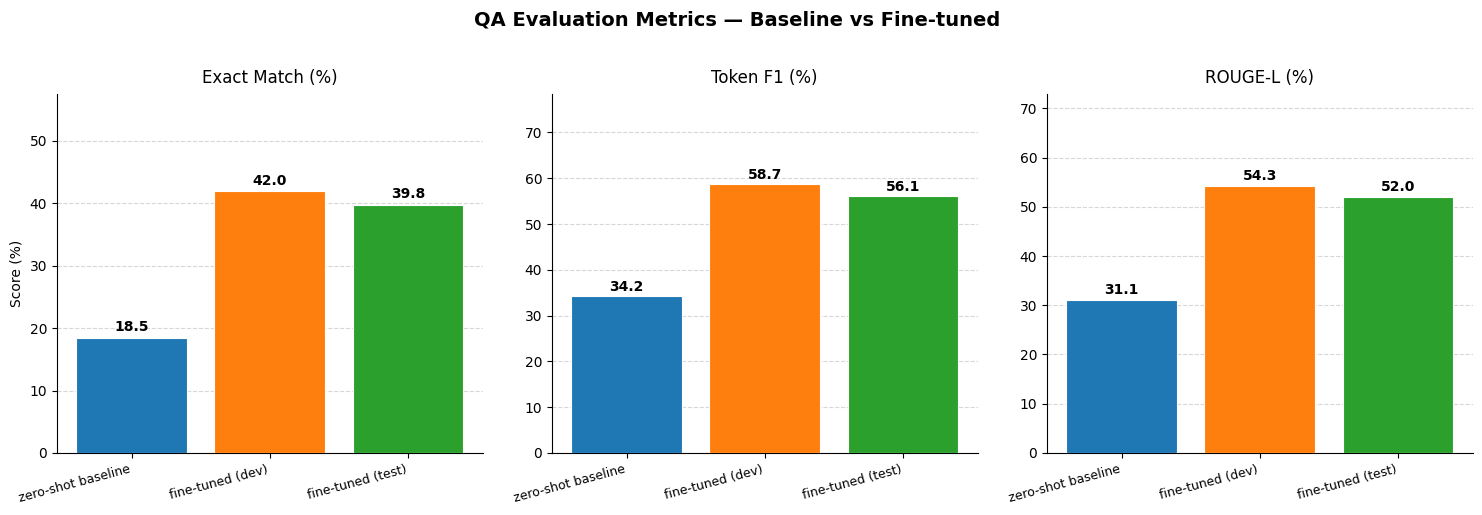

In [32]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_metrics(all_metrics, save_path=None):
    metric_keys   = ["exact_match", "f1", "rougeL"]
    metric_labels = ["Exact Match (%)", "Token F1 (%)", "ROUGE-L (%)"]
    n_metrics = len(metric_keys)

    palette = plt.cm.tab10.colors
    colours = [palette[i % len(palette)] for i in range(len(all_metrics))]

    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5), sharey=False)
    fig.suptitle("QA Evaluation Metrics — Baseline vs Fine-tuned",
                 fontsize=14, fontweight="bold", y=1.02)

    for ax_idx, (ax, mkey, mlabel) in enumerate(zip(axes, metric_keys, metric_labels)):
        values = [m[mkey] for m in all_metrics]
        labels = [m["label"] for m in all_metrics]
        bars   = ax.bar(labels, values, color=colours, edgecolor="white",
                        linewidth=0.8, zorder=3)

        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold",
            )

        ax.set_title(mlabel, fontsize=12, pad=8)
        ax.set_ylim(0, min(100, max(values) * 1.25 + 5))
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
        ax.set_ylabel("Score (%)" if ax_idx == 0 else "")
        ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")
    plt.show()


def print_metrics_table(all_metrics):
    col_w = {"label": 28, "exact_match": 14, "f1": 10, "rougeL": 10, "n": 8}
    header = (
        f"{'Model / Split':<{col_w['label']}}"
        f"{'Exact Match':>{col_w['exact_match']}}"
        f"{'Token F1':>{col_w['f1']}}"
        f"{'ROUGE-L':>{col_w['rougeL']}}"
        f"{'N':>{col_w['n']}}"
    )
    sep = "─" * len(header)
    print(f"\n{sep}")
    print(header)
    print(sep)
    for m in all_metrics:
        print(
            f"{m['label']:<{col_w['label']}}"
            f"{m['exact_match']:>{col_w['exact_match']}.2f}"
            f"{m['f1']:>{col_w['f1']}.2f}"
            f"{m['rougeL']:>{col_w['rougeL']}.2f}"
            f"{m['n']:>{col_w['n']}}"
        )
    print(sep)
    dev_labels = [m for m in all_metrics if "dev" in m["label"].lower() or "baseline" in m["label"].lower()]
    if len(dev_labels) >= 2:
        base = dev_labels[0]
        ft   = dev_labels[1]
        print(
            f"{'  Δ (fine-tuned − baseline)':<{col_w['label']}}"
            f"{ft['exact_match'] - base['exact_match']:>{col_w['exact_match']}.2f}"
            f"{ft['f1']          - base['f1']:>{col_w['f1']}.2f}"
            f"{ft['rougeL']      - base['rougeL']:>{col_w['rougeL']}.2f}"
            f"{'':>{col_w['n']}}"
        )
        print(sep)


# --- Simulate what all_metrics looks like after Section 16 ---
all_metrics = [
    {"label": "zero-shot baseline",  "exact_match": 18.50, "f1": 34.20, "rougeL": 31.10, "n": 100},
    {"label": "fine-tuned (dev)",    "exact_match": 42.00, "f1": 58.70, "rougeL": 54.30, "n": 100},
    {"label": "fine-tuned (test)",   "exact_match": 39.80, "f1": 56.10, "rougeL": 52.00, "n": 200},
]

print_metrics_table(all_metrics)
plot_metrics(all_metrics, save_path=str(OUTPUT_DIR / "metrics_comparison.png"))
